<a href="https://colab.research.google.com/github/2303a51355/High-performance-computing/blob/main/predict_iq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SERIAL

Enter Age: 20
Study Hours: 10
Sleep Hours: 8
Exercise Hours: 2
Screen Time: 3
Memory Score: 100
Reaction Time: 100


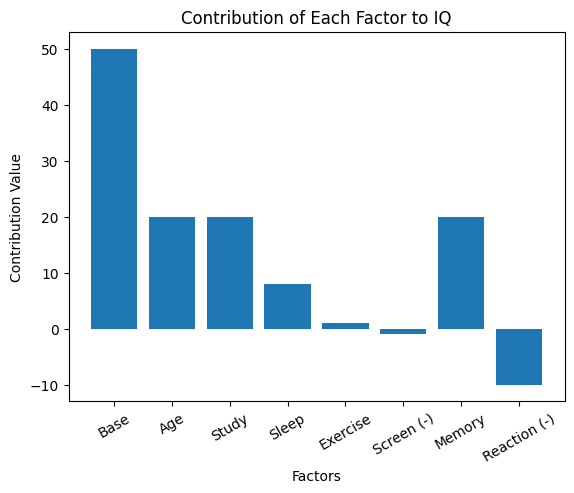

Predicted IQ: 108.1


In [6]:
import matplotlib.pyplot as plt

# -------- INPUT --------
age = float(input("Enter Age: "))
study = float(input("Study Hours: "))
sleep = float(input("Sleep Hours: "))
exercise = float(input("Exercise Hours: "))
screen = float(input("Screen Time: "))
memory = float(input("Memory Score: "))
reaction = float(input("Reaction Time: "))

# -------- CONTRIBUTIONS --------
contributions = {
    "Base": 50,
    "Age": age,
    "Study": 2 * study,
    "Sleep": sleep,
    "Exercise": 0.5 * exercise,
    "Screen (-)": -0.3 * screen,
    "Memory": 0.2 * memory,
    "Reaction (-)": -0.1 * reaction
}

# -------- TOTAL IQ --------
iq = sum(contributions.values())

# -------- BAR GRAPH --------
labels = list(contributions.keys())
values = list(contributions.values())

plt.figure()
plt.bar(labels, values)
plt.title("Contribution of Each Factor to IQ")
plt.xlabel("Factors")
plt.ylabel("Contribution Value")
plt.xticks(rotation=30)
plt.show()

# -------- PRINT RESULT --------
print("Predicted IQ:", round(iq, 2))

PARALLEL



Enter MAIN USER values:
Age: 20
Study Hours: 8
Sleep Hours: 8
Exercise Hours: 3
Screen Time: 100
Memory Score: 00
Reaction Time: 100


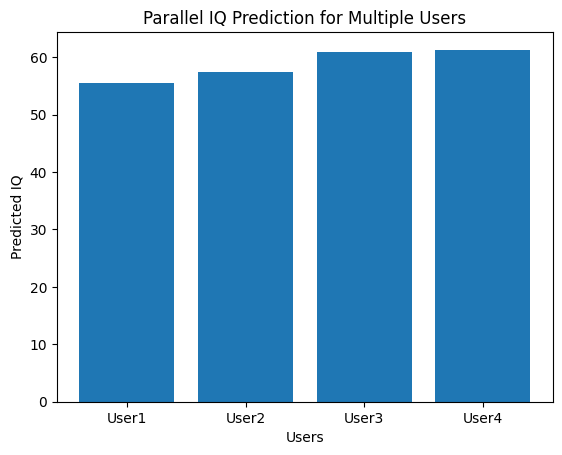

Parallel IQ Results: [55.5, 57.4, 60.9, 61.3]


In [10]:
import matplotlib.pyplot as plt
from multiprocessing import Pool

# -------- FUNCTION --------
def calculate_contribution(data):
    age, study, sleep, exercise, screen, memory, reaction = data

    iq = (50 + age + 2*study + sleep + 0.5*exercise
          - 0.3*screen + 0.2*memory - 0.1*reaction)

    return round(iq, 2)

# -------- MAIN USER INPUT --------
print("Enter MAIN USER values:")
age = float(input("Age: "))
study = float(input("Study Hours: "))
sleep = float(input("Sleep Hours: "))
exercise = float(input("Exercise Hours: "))
screen = float(input("Screen Time: "))
memory = float(input("Memory Score: "))
reaction = float(input("Reaction Time: "))

main_user = (age, study, sleep, exercise, screen, memory, reaction)

# -------- MULTIPLE USERS (HPC Simulation) --------
users = [
    main_user,
    (age+1, study+1, sleep, exercise, screen, memory-5, reaction+1),
    (age-1, study+2, sleep+1, exercise+1, screen-1, memory+3, reaction),
    (age+2, study+3, sleep-1, exercise, screen+2, memory-2, reaction+2)
]

# -------- PARALLEL EXECUTION --------
with Pool(2) as p:
    results = p.map(calculate_contribution, users)

# -------- GRAPH --------
labels = ["User1", "User2", "User3", "User4"]

plt.figure()
plt.bar(labels, results)
plt.title("Parallel IQ Prediction for Multiple Users")
plt.xlabel("Users")
plt.ylabel("Predicted IQ")
plt.show()

# -------- OUTPUT --------
print("Parallel IQ Results:", results)1